# Config A — Q-Learning (Tabular RL)

Discrete state space: 716 states × 25 actions.  
Algorithm: Q-Learning.

In [ ]:
import sys, os
# Ensure project root is importable regardless of how this notebook was launched
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
os.chdir(project_root)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from envs.env_setup import make_sepsis_env, N_STATES, N_ACTIONS
from agents.config_a.q_learning import QLearningAgent, QLearningConfig
from utils.evaluation import eval_agent, print_results
from utils.plotting import plot_training_curve, plot_comparison
import optuna
import numpy as np
import copy

SEED = 42
np.random.seed(SEED)
print(f'States: {N_STATES}, Actions: {N_ACTIONS}')

States: 716, Actions: 25


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## 1. Random Baseline

In [3]:
env = make_sepsis_env()
random_policy = lambda obs: env.action_space.sample()
random_results = eval_agent(random_policy, make_sepsis_env)
print_results('Random Baseline (Config A)', random_results)

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
=== Random Baseline (Config A) ===
  Mean return  : 0.6325 ± 0.4437
  Survival rate: 73.8%
  Mean ep len  : 10.6


## 2. Q-Learning

### Hyperparameter Configuration

**Note**: You can tune these hyperparameters to improve performance:
- `alpha`: Learning rate (how much new information overrides old)
- `gamma`: Discount factor (importance of future rewards)
- `epsilon_start` & `epsilon_end`: Exploration-exploitation trade-off
- `epsilon_decay`: Number of steps over which epsilon decays linearly
- `n_episodes`: Number of training episodes

### Default Hyper Parameters

In [5]:
cfg_ql = QLearningConfig(
    alpha=0.1,
    gamma=1.0,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay=50_000,
    n_episodes=5_000,
)
ql_agent = QLearningAgent(N_STATES, N_ACTIONS, cfg_ql)

print(f'Training Q-Learning for {cfg_ql.n_episodes} episodes...')
ql_returns = ql_agent.train(lambda: make_sepsis_env(verbose=False), verbose=True, verbose_interval=250)
print('Training complete!')

Training Q-Learning for 5000 episodes...
Episode 250/5000 | Avg Return (last 250): 0.599 | Elapsed: 62.2s | ETA: 1181.0s
Episode 500/5000 | Avg Return (last 250): 0.590 | Elapsed: 123.3s | ETA: 1109.9s
Episode 750/5000 | Avg Return (last 250): 0.597 | Elapsed: 185.9s | ETA: 1053.3s
Episode 1000/5000 | Avg Return (last 250): 0.607 | Elapsed: 247.4s | ETA: 989.8s
Episode 1250/5000 | Avg Return (last 250): 0.580 | Elapsed: 308.2s | ETA: 924.6s
Episode 1500/5000 | Avg Return (last 250): 0.635 | Elapsed: 512.2s | ETA: 1195.1s
Episode 1750/5000 | Avg Return (last 250): 0.670 | Elapsed: 574.0s | ETA: 1066.0s
Episode 2000/5000 | Avg Return (last 250): 0.608 | Elapsed: 635.5s | ETA: 953.2s
Episode 2250/5000 | Avg Return (last 250): 0.643 | Elapsed: 696.5s | ETA: 851.3s
Episode 2500/5000 | Avg Return (last 250): 0.601 | Elapsed: 759.0s | ETA: 759.0s
Episode 2750/5000 | Avg Return (last 250): 0.581 | Elapsed: 820.0s | ETA: 670.9s
Episode 3000/5000 | Avg Return (last 250): 0.596 | Elapsed: 885.1s 

In [6]:
# Evaluate the trained Q-Learning agent
ql_results = eval_agent(ql_agent.get_policy(), make_sepsis_env)
print_results('Q-Learning (Config A)', ql_results)

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
=== Q-Learning (Config A) ===
  Mean return  : 0.6453 ± 0.4447
  Survival rate: 73.1%
  Mean ep len  : 10.1


<Axes: xlabel='Episode', ylabel='Return'>

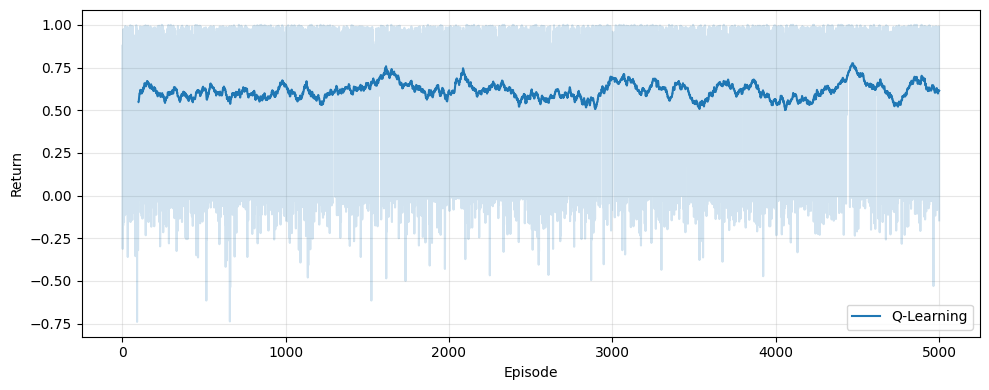

In [7]:
# Visualize the training curve
plot_training_curve(ql_returns, label='Q-Learning', save_path='plots/configA_qlearning_curve.png')

#### Comparison with Baseline

<Axes: title={'center': 'Config A — Q-Learning vs Random Baseline'}, ylabel='Survival Rate'>

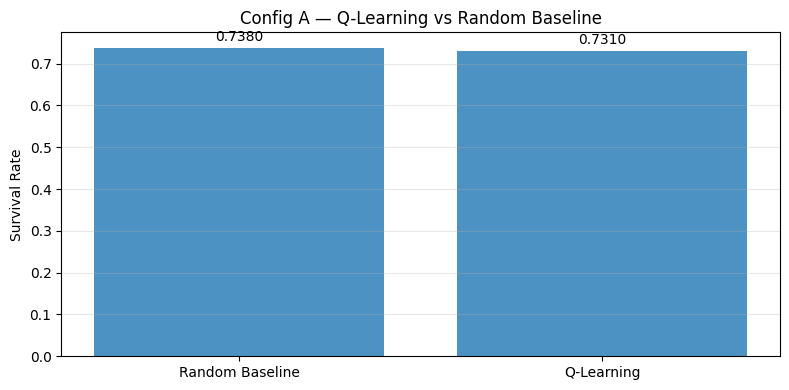

In [8]:
# Compare Q-Learning against Random baseline
comparison_results = {
    'Random Baseline': random_results,
    'Q-Learning': ql_results,
}
plot_comparison(comparison_results, metric='survival_rate', title='Config A — Q-Learning vs Random Baseline',
                save_path='plots/configA_qlearning_vs_random.png')

### Conservative Hyper Parameters

In [10]:
cfg_ql_conservative = QLearningConfig(
    alpha=0.05,
    gamma=1.0,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay=75_000,
    n_episodes=5_000,
)
ql_agent_conservative = QLearningAgent(N_STATES, N_ACTIONS, cfg_ql_conservative)

print(f'Training Q-Learning for {cfg_ql_conservative.n_episodes} episodes...')
ql_returns_conservative = ql_agent_conservative.train(lambda: make_sepsis_env(verbose=False), verbose=True, verbose_interval=250)
print('Training complete!')

Training Q-Learning for 5000 episodes...
Episode 250/5000 | Avg Return (last 250): 0.577 | Elapsed: 62.8s | ETA: 1193.4s
Episode 500/5000 | Avg Return (last 250): 0.627 | Elapsed: 124.9s | ETA: 1124.3s
Episode 750/5000 | Avg Return (last 250): 0.606 | Elapsed: 188.0s | ETA: 1065.3s
Episode 1000/5000 | Avg Return (last 250): 0.597 | Elapsed: 249.5s | ETA: 998.0s
Episode 1250/5000 | Avg Return (last 250): 0.657 | Elapsed: 310.3s | ETA: 930.9s
Episode 1500/5000 | Avg Return (last 250): 0.576 | Elapsed: 430.8s | ETA: 1005.2s
Episode 1750/5000 | Avg Return (last 250): 0.656 | Elapsed: 493.7s | ETA: 916.9s
Episode 2000/5000 | Avg Return (last 250): 0.632 | Elapsed: 555.7s | ETA: 833.6s
Episode 2250/5000 | Avg Return (last 250): 0.634 | Elapsed: 617.4s | ETA: 754.6s
Episode 2500/5000 | Avg Return (last 250): 0.653 | Elapsed: 678.4s | ETA: 678.4s
Episode 2750/5000 | Avg Return (last 250): 0.646 | Elapsed: 742.5s | ETA: 607.5s
Episode 3000/5000 | Avg Return (last 250): 0.607 | Elapsed: 805.7s |

In [11]:
# Evaluate the trained Q-Learning agent
ql_results_conservative = eval_agent(ql_agent_conservative.get_policy(), make_sepsis_env)
print_results('Q-Learning (Config A)', ql_results_conservative)

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
=== Q-Learning (Config A) ===
  Mean return  : 0.6529 ± 0.4413
  Survival rate: 73.4%
  Mean ep len  : 9.9


<Axes: xlabel='Episode', ylabel='Return'>

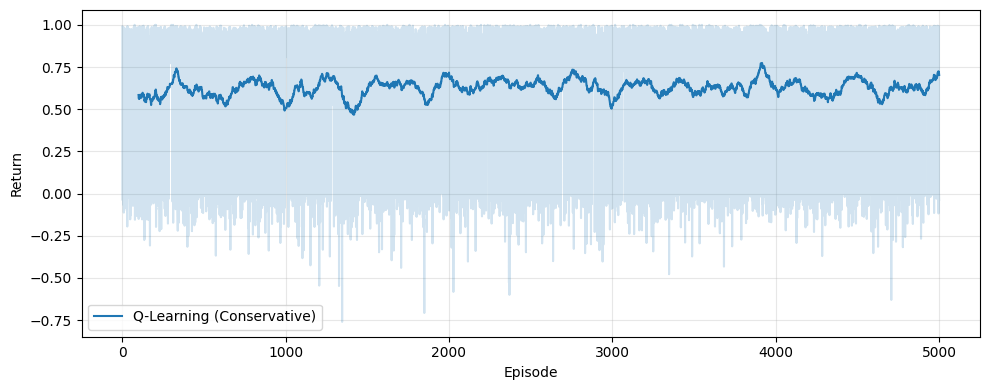

In [12]:
# Visualize the training curve
plot_training_curve(ql_returns_conservative, label='Q-Learning (Conservative)', save_path='plots/configA_qlearning_curve_conservative.png')

#### Comparison with Baseline

<Axes: title={'center': 'Config A — Q-Learning (Conservative) vs Random Baseline'}, ylabel='Survival Rate'>

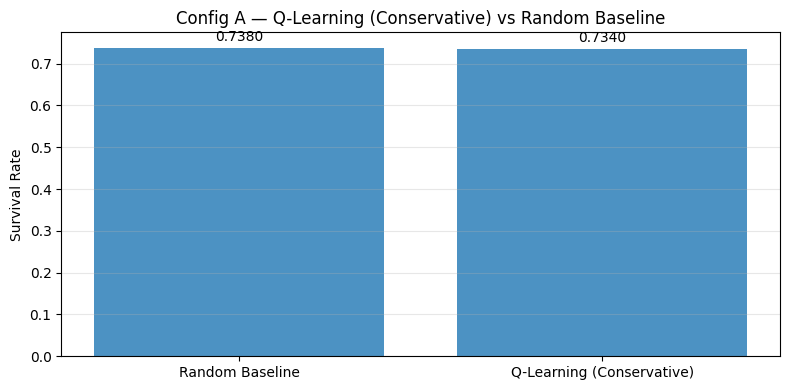

In [13]:
# Compare Q-Learning against Random baseline
comparison_results = {
    'Random Baseline': random_results,
    'Q-Learning (Conservative)': ql_results_conservative,
}
plot_comparison(comparison_results, metric='survival_rate', title='Config A — Q-Learning (Conservative) vs Random Baseline',
                save_path='plots/configA_qlearning_conservative_vs_random.png')

### Aggressive Hyper Parameters

In [14]:
cfg_ql_aggressive = QLearningConfig(
    alpha=0.2,
    gamma=1.0,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay=25_000,
    n_episodes=5_000,
)
ql_agent_aggressive = QLearningAgent(N_STATES, N_ACTIONS, cfg_ql_aggressive)

print(f'Training Q-Learning for {cfg_ql_aggressive.n_episodes} episodes...')
ql_returns_aggressive = ql_agent_aggressive.train(lambda: make_sepsis_env(verbose=False), verbose=True, verbose_interval=250)
print('Training complete!')

Training Q-Learning for 5000 episodes...
Episode 250/5000 | Avg Return (last 250): 0.590 | Elapsed: 61.5s | ETA: 1168.8s
Episode 500/5000 | Avg Return (last 250): 0.614 | Elapsed: 124.2s | ETA: 1117.8s
Episode 750/5000 | Avg Return (last 250): 0.636 | Elapsed: 186.4s | ETA: 1056.0s
Episode 1000/5000 | Avg Return (last 250): 0.617 | Elapsed: 346.8s | ETA: 1387.3s
Episode 1250/5000 | Avg Return (last 250): 0.636 | Elapsed: 633.8s | ETA: 1901.4s
Episode 1500/5000 | Avg Return (last 250): 0.586 | Elapsed: 696.2s | ETA: 1624.5s
Episode 1750/5000 | Avg Return (last 250): 0.659 | Elapsed: 759.6s | ETA: 1410.7s
Episode 2000/5000 | Avg Return (last 250): 0.685 | Elapsed: 822.2s | ETA: 1233.2s
Episode 2250/5000 | Avg Return (last 250): 0.601 | Elapsed: 885.3s | ETA: 1082.0s
Episode 2500/5000 | Avg Return (last 250): 0.648 | Elapsed: 948.9s | ETA: 948.9s
Episode 2750/5000 | Avg Return (last 250): 0.605 | Elapsed: 1012.5s | ETA: 828.4s
Episode 3000/5000 | Avg Return (last 250): 0.632 | Elapsed: 10

In [15]:
# Evaluate the trained Q-Learning agent
ql_results_aggressive = eval_agent(ql_agent_aggressive.get_policy(), make_sepsis_env)
print_results('Q-Learning (Config A)', ql_results_aggressive)

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
=== Q-Learning (Config A) ===
  Mean return  : 0.6568 ± 0.4407
  Survival rate: 74.0%
  Mean ep len  : 10.2


<Axes: xlabel='Episode', ylabel='Return'>

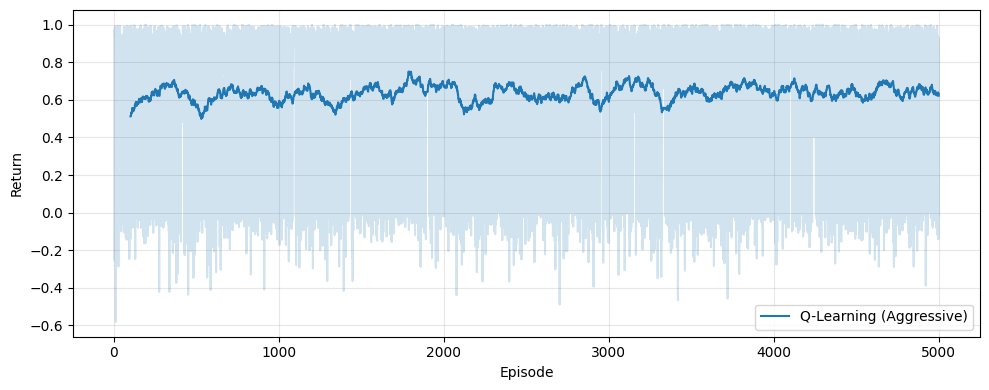

In [16]:
# Visualize the training curve
plot_training_curve(ql_returns_aggressive, label='Q-Learning (Aggressive)', save_path='plots/configA_qlearning_curve_aggressive.png')

#### Comparison with Baseline

<Axes: title={'center': 'Config A — Q-Learning (Aggressive) vs Random Baseline'}, ylabel='Survival Rate'>

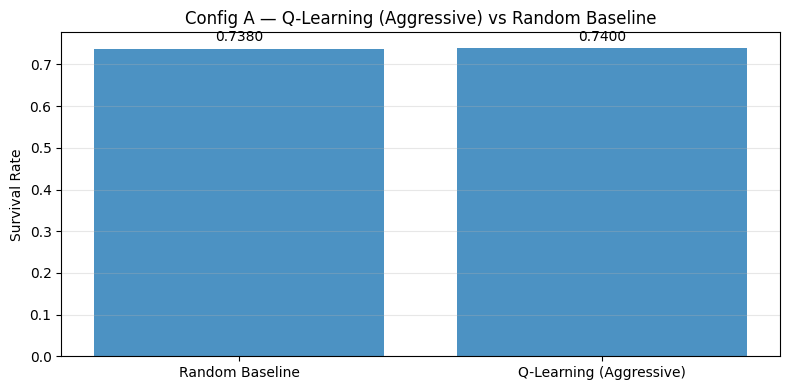

In [17]:
# Compare Q-Learning against Random baseline
comparison_results = {
    'Random Baseline': random_results,
    'Q-Learning (Aggressive)': ql_results_aggressive,
}
plot_comparison(comparison_results, metric='survival_rate', title='Config A — Q-Learning (Aggressive) vs Random Baseline',
                save_path='plots/configA_qlearning_aggressive_vs_random.png')

## 3. Optuna Hyperparameter Search

In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

OPTUNA_MODE = "final"

OPTUNA_SETTINGS = {
    "classroom": {
        "n_trials": 8,
        "trial_episodes": 3_000,
        "n_validation_episodes": 20,
    },
    "final": {
        "n_trials": 15,
        "trial_episodes": 5_000,
        "n_validation_episodes": 30,
    },
}
optuna_settings = OPTUNA_SETTINGS[OPTUNA_MODE]

BASELINE_SEARCH_TRIAL = {
    "alpha": 0.1,
    "gamma": 1.0,
    "epsilon_decay": 50_000,
    "epsilon_end": 0.05,
    "exploration_episodes": 2_000,
}

# Storage for trained trials (mirrors your DQN pattern)
trial_checkpoint_qtables = {}
trial_ql_parameters = {}
trial_training_returns = {}


def build_trial_parameters(trial):
    """Ask Optuna for one Q-Learning configuration."""
    return {
        "alpha": trial.suggest_float("alpha", 0.01, 0.5, log=True),
        "gamma": trial.suggest_float("gamma", 0.90, 1.0),
        "epsilon_decay": trial.suggest_categorical(
            "epsilon_decay", [25_000, 50_000, 75_000, 100_000]
        ),
        "epsilon_end": trial.suggest_categorical(
            "epsilon_end", [0.01, 0.05, 0.10]
        ),
        "exploration_episodes": trial.suggest_categorical(
            "exploration_episodes", [1_000, 2_000, 3_000]
        ),
    }


def optuna_ql_objective(trial):
    """Train one Optuna trial and return its mean validation survival rate."""
    params = build_trial_parameters(trial)

    cfg = QLearningConfig(
        alpha=params["alpha"],
        gamma=params["gamma"],
        epsilon_start=1.0,
        epsilon_end=params["epsilon_end"],
        epsilon_decay=params["epsilon_decay"],
        exploration_episodes=params["exploration_episodes"],
        n_episodes=optuna_settings["trial_episodes"],
    )

    agent = QLearningAgent(N_STATES, N_ACTIONS, cfg)
    training_returns = agent.train(
        lambda: make_sepsis_env(verbose=False),
        verbose=False,
    )

    # Evaluate on fixed seeds (mirrors evaluate_sb3_fixed_seeds)
    validation_results = eval_agent(
        agent.get_policy(),
        make_sepsis_env,
        n_episodes=optuna_settings["n_validation_episodes"],
    )
    mean_survival = validation_results["survival_rate"]

    # Store checkpoint so we don't retrain later
    trial_checkpoint_qtables[trial.number] = copy.deepcopy(agent.Q)
    trial_ql_parameters[trial.number] = copy.deepcopy(params)
    trial_training_returns[trial.number] = training_returns.copy()

    trial.set_user_attr("mean_survival", float(mean_survival))

    return float(mean_survival)


# --- Run the search ---
sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction="maximize", sampler=sampler)

# Baseline first (your current default config)
study.enqueue_trial(BASELINE_SEARCH_TRIAL)

# Two additional sensible starting points
study.enqueue_trial({
    "alpha": 0.05,
    "gamma": 1.0,
    "epsilon_decay": 75_000,
    "epsilon_end": 0.05,
    "exploration_episodes": 2_000,
})
study.enqueue_trial({
    "alpha": 0.2,
    "gamma": 1.0,
    "epsilon_decay": 25_000,
    "epsilon_end": 0.10,
    "exploration_episodes": 1_000,
})

study.optimize(
    optuna_ql_objective,
    n_trials=optuna_settings["n_trials"],
    show_progress_bar=True,
)

# --- Results ---
best_trial = study.best_trial
baseline_trial = study.trials[0]

print(f"Optuna mode: {OPTUNA_MODE}")
print(f"Number of trials: {len(study.trials)}")
print(f"Baseline survival rate: {baseline_trial.value:.4f}")
print(f"Selected trial: {best_trial.number}")
print(f"Best survival rate:     {best_trial.value:.4f}")
print(f"Improvement over baseline: {best_trial.value - baseline_trial.value:+.4f}")
print("\nSelected hyperparameters:")
for param, value in best_trial.params.items():
    print(f"  {param}: {value}")

# --- Restore best agent without retraining ---
best_cfg = QLearningConfig(
    **{k: v for k, v in trial_ql_parameters[best_trial.number].items()},
    epsilon_start=1.0,
    n_episodes=optuna_settings["trial_episodes"],
)
best_agent = QLearningAgent(N_STATES, N_ACTIONS, best_cfg)
best_agent.Q = trial_checkpoint_qtables[best_trial.number]

## 4. Analysis

In [ ]:
# Define your three agents
agents = {
    'Default': (ql_agent, ql_returns),
    'Conservative': (ql_agent_conservative, ql_returns_conservative),
    'Aggressive': (ql_agent_aggressive, ql_returns_aggressive),
}

print("\n" + "="*80)
print("Q-LEARNING HYPERPARAMETER COMPARISON")
print("="*80)

# Create comparison dataframe
comparison_data = []

for config_name, (agent, returns) in agents.items():
    avg_first_100 = np.mean(returns[:100])
    avg_last_100 = np.mean(returns[-100:])
    improvement = avg_last_100 - avg_first_100
    
    comparison_data.append({
        'Config': config_name,
        'Avg Return (First 100)': f"{avg_first_100:.3f}",
        'Avg Return (Last 100)': f"{avg_last_100:.3f}",
        'Improvement': f"{improvement:.3f}",
        'Q-table Max (mean)': f"{np.max(agent.Q, axis=1).mean():.3f}",
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# Detailed hyperparameters
print("\n" + "="*80)
print("HYPERPARAMETERS USED")
print("="*80)

configs = {
    'Default': cfg_ql,
    'Conservative': cfg_ql_conservative,
    'Aggressive': cfg_ql_aggressive,
}

for config_name, cfg in configs.items():
    print(f"\n{config_name}:")
    print(f"  alpha={cfg.alpha}")
    print(f"  gamma={cfg.gamma}")
    print(f"  epsilon_start={cfg.epsilon_start} → epsilon_end={cfg.epsilon_end}")
    print(f"  epsilon_decay={cfg.epsilon_decay}")
    print(f"  n_episodes={cfg.n_episodes}")

# Evaluate all three and compare
print("\n" + "="*80)
print("EVALUATION RESULTS")
print("="*80)

eval_data = []
for config_name, (agent, _) in agents.items():
    policy = agent.get_policy()
    results = eval_agent(policy, make_sepsis_env)
    
    eval_data.append({
        'Config': config_name,
        'Survival Rate': f"{results['survival_rate']:.4f}",
        'Avg Reward': f"{results.get('avg_reward', 'N/A')}",
    })

eval_df = pd.DataFrame(eval_data)
print(eval_df.to_string(index=False))

# Determine best
print("\n" + "="*80)
print("BEST CONFIGURATION")
print("="*80)

best_config = max(agents.items(), 
                  key=lambda x: eval_agent(x[1][0].get_policy(), make_sepsis_env)['survival_rate'])
print(f"✓ WINNER: {best_config[0]}")
print(f"  (Highest survival rate)")


Q-LEARNING HYPERPARAMETER COMPARISON
      Config Avg Return (First 100) Avg Return (Last 100) Improvement Q-table Max (mean)
     Default                  0.548                 0.615       0.066              0.252
Conservative                  0.584                 0.703       0.119              0.114
  Aggressive                  0.513                 0.623       0.110              0.488

HYPERPARAMETERS USED

Default:
  alpha=0.1
  gamma=1.0
  epsilon_start=1.0 → epsilon_end=0.05
  epsilon_decay=50000
  n_episodes=5000

Conservative:
  alpha=0.05
  gamma=1.0
  epsilon_start=1.0 → epsilon_end=0.05
  epsilon_decay=75000
  n_episodes=5000

Aggressive:
  alpha=0.2
  gamma=1.0
  epsilon_start=1.0 → epsilon_end=0.05
  epsilon_decay=25000
  n_episodes=5000

EVALUATION RESULTS
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9